In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.7 MB/s eta 0:00:00


In [3]:
!pip install shap -q

# 18 — SHAP Explainability
### Early Sepsis Detection — Phase 20

Explains **LightGBM (tuned)** — the strongest tree-based model — using
SHAP (SHapley Additive exPlanations).

**Important note on calibration:** SHAP explains the underlying LightGBM
model's raw decision function directly (not the isotonic-calibrated
wrapper from Phase 19), since SHAP's TreeExplainer requires direct access
to the tree structure. Calibration only rescales the final probability
monotonically — it does not change which features drove the ranking, so
this remains a faithful explanation of what the deployed model actually
uses to distinguish high- from low-risk patients.

**SHAP values show model associations/contributions, not medical
causality** — this is stated once here and applies to every plot below.


In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

from src import config

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]

model = joblib.load(config.MODELS_DIR / "lightgbm_tuned.pkl")
feature_names = pd.read_csv(config.PROCESSED_DIR / "feature_names.csv")["feature_name"].tolist()

X_val_df = pd.DataFrame(X_val, columns=feature_names)
print("Ready:", X_val_df.shape)


Ready: (5905, 464)


## 1. Compute SHAP values (TreeExplainer — exact, fast for tree models)

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_df)

# LightGBM binary classifier via TreeExplainer returns a single array of
# shap values for the positive class (or a list of two arrays in older
# shap/lightgbm combinations) — handle both defensively.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# expected_value can be a scalar or a 2-element array depending on shap/
# lightgbm version — normalize to a scalar for the positive class here so
# the waterfall plots in Section 5 don't need to handle both cases later.
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else float(np.atleast_1d(expected_value)[0])

print("SHAP values shape:", shap_values.shape)
print("Base value (expected_value):", expected_value)


SHAP values shape: (5905, 464)
Base value (expected_value): -1.1390964522554392


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 2. Global feature importance — bar plot (mean |SHAP value|)

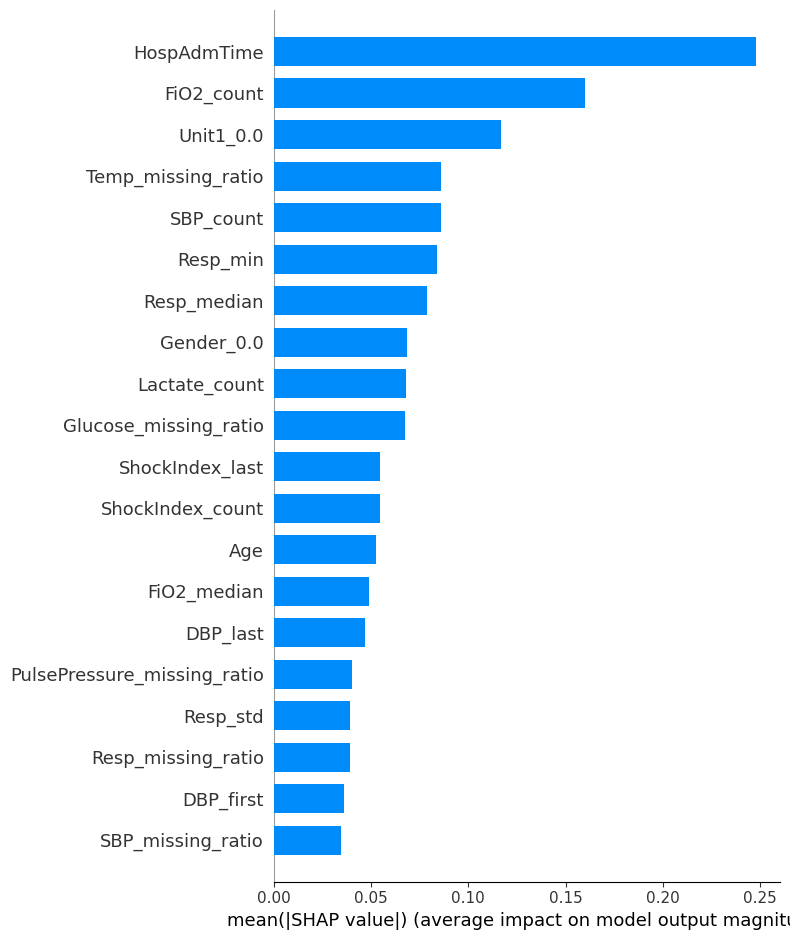

In [6]:
shap.summary_plot(shap_values, X_val_df, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "18_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Beeswarm plot — direction AND magnitude of effect

Shows not just which features matter, but whether high/low values of each
push the prediction toward higher or lower sepsis risk.


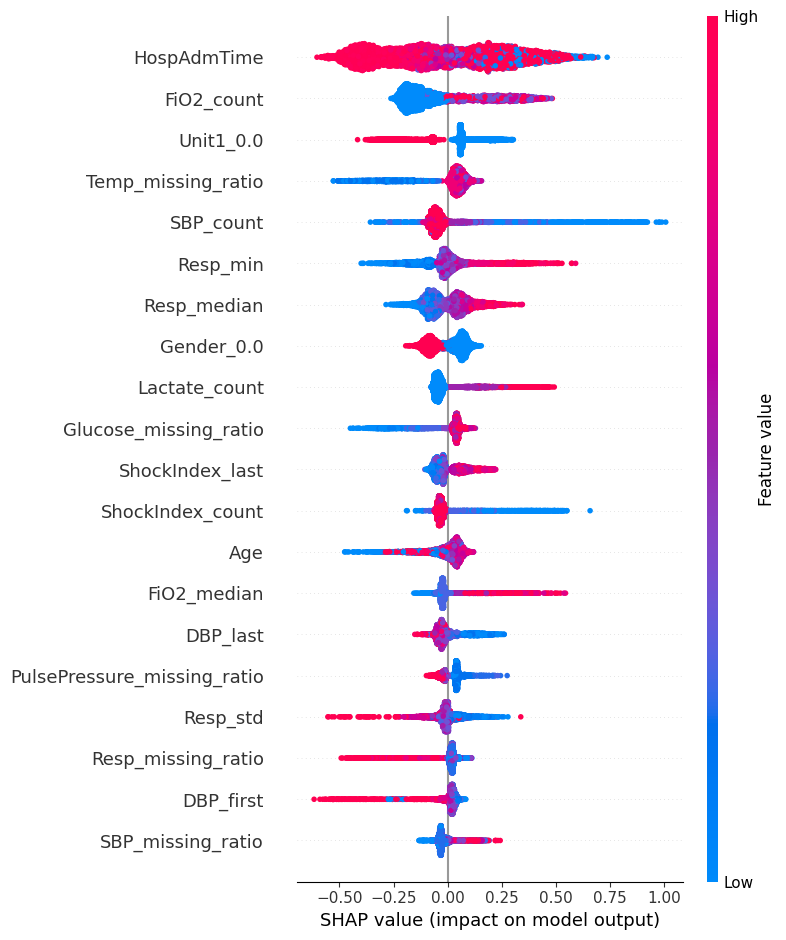

In [7]:
shap.summary_plot(shap_values, X_val_df, max_display=20, show=False)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "18_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Dependence plots for the top 3 features

Shows how a single feature's value relates to its SHAP contribution,
including any interaction effects (colored by the most correlated
interacting feature, chosen automatically by SHAP).


Top 3 features by mean |SHAP value|: ['HospAdmTime', 'FiO2_count', 'Unit1_0.0']


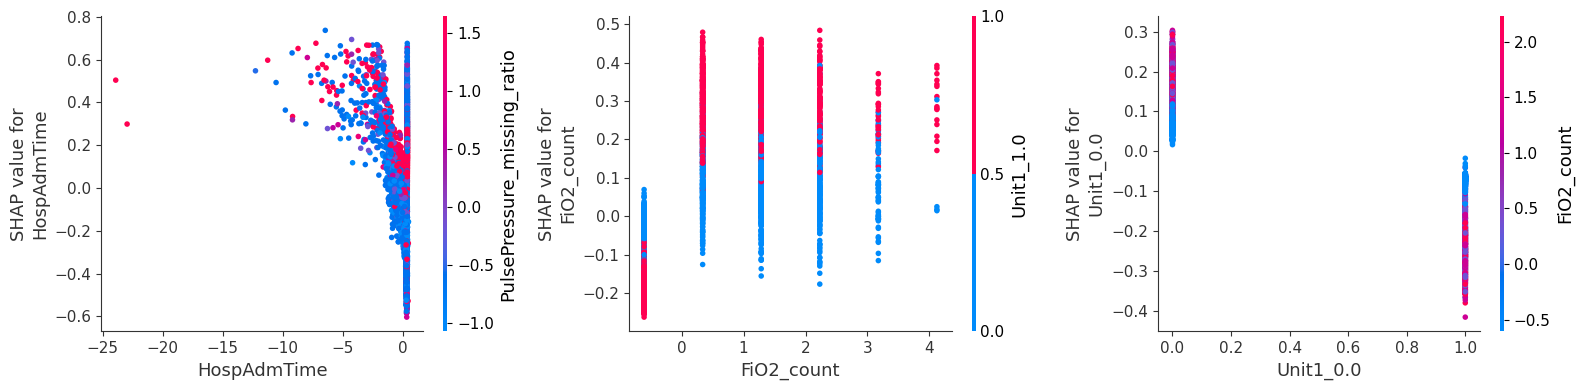

In [8]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_features = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(3).index.tolist()
print("Top 3 features by mean |SHAP value|:", top3_features)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(feat, shap_values, X_val_df, ax=ax, show=False)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "18_shap_dependence_top3.png", dpi=150)
plt.show()


## 5. Individual patient explanations

**Answers: "Why did the model classify THIS patient as high risk?"**

Two examples are chosen deliberately:
1. A confidently-correct positive prediction (true positive, high probability)
2. A false negative (actually positive, but the model scored it low) —
   understanding these is exactly Phase 21's Error Analysis focus, previewed here.


In [9]:
val_prob = model.predict_proba(X_val)[:, 1]
val_pred = (val_prob >= 0.5).astype(int)  # illustrative only; Phase 18's real threshold is 0.1 post-calibration

# Confident true positive
tp_mask = (y_val == 1) & (val_prob > 0.7)
tp_idx = np.where(tp_mask)[0][0] if tp_mask.any() else np.where(y_val == 1)[0][0]

# A false negative (positive patient the model scored low)
fn_mask = (y_val == 1) & (val_prob < 0.2)
fn_idx = np.where(fn_mask)[0][0] if fn_mask.any() else None

print(f"True positive example: index {tp_idx}, predicted probability = {val_prob[tp_idx]:.3f}")
if fn_idx is not None:
    print(f"False negative example: index {fn_idx}, predicted probability = {val_prob[fn_idx]:.3f}")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


True positive example: index 28, predicted probability = 0.701
False negative example: index 475, predicted probability = 0.139


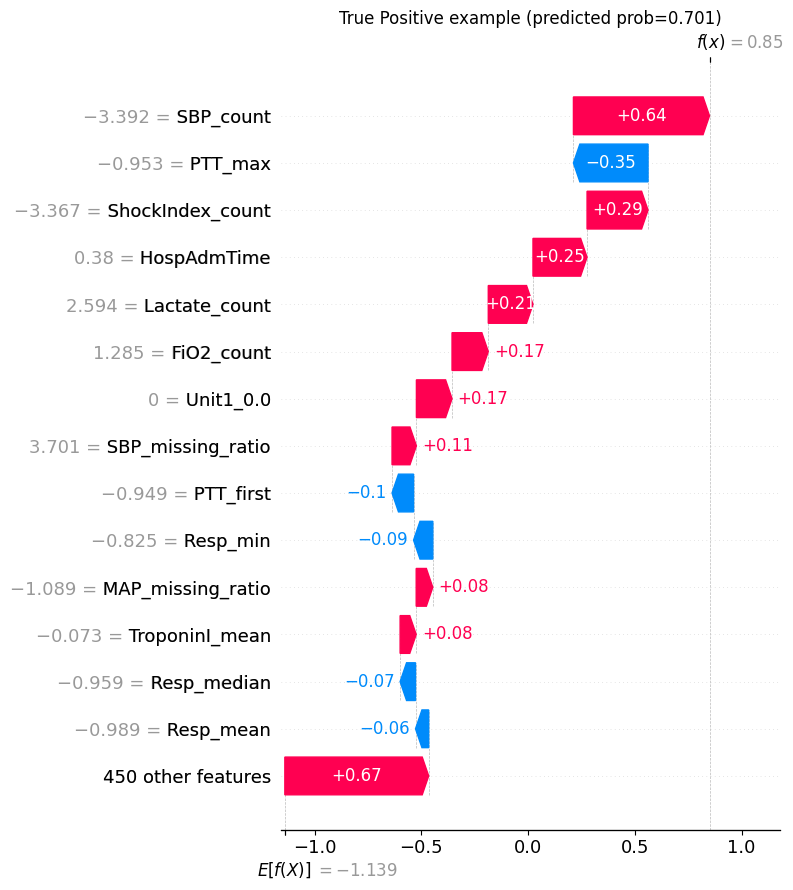

In [10]:
explanation_tp = shap.Explanation(
    values=shap_values[tp_idx], base_values=expected_value,
    data=X_val_df.iloc[tp_idx], feature_names=feature_names,
)
shap.plots.waterfall(explanation_tp, max_display=15, show=False)
plt.title(f"True Positive example (predicted prob={val_prob[tp_idx]:.3f})")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "18_shap_waterfall_true_positive.png", dpi=150, bbox_inches="tight")
plt.show()


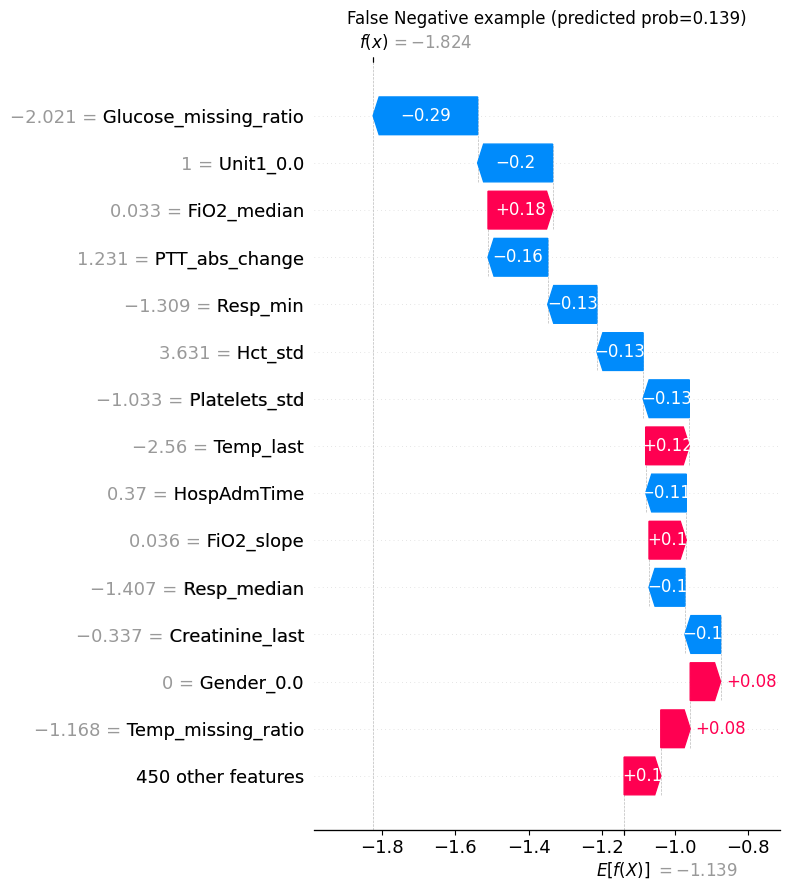

In [11]:
if fn_idx is not None:
    explanation_fn = shap.Explanation(
        values=shap_values[fn_idx], base_values=expected_value,
        data=X_val_df.iloc[fn_idx], feature_names=feature_names,
    )
    shap.plots.waterfall(explanation_fn, max_display=15, show=False)
    plt.title(f"False Negative example (predicted prob={val_prob[fn_idx]:.3f})")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "18_shap_waterfall_false_negative.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No false-negative example found at this strict threshold — try relaxing the cutoff.")


## 6. Save SHAP values for reuse in Phase 21 (Error Analysis)

In [12]:
np.save(config.PROCESSED_DIR / "shap_values_val.npy", shap_values)
print("Saved SHAP values for Phase 21.")


Saved SHAP values for Phase 21.


---
### What to send back to Claude after running this notebook

- Section 2's bar plot — top 10 features by importance
- Section 3's beeswarm plot — do high values of top features push risk up
  or down, and does that match clinical expectation (e.g. does high
  Lactate_count push risk up)?
- Section 5's two waterfall plots — what pushed the true positive toward
  high risk, and what kept the false negative's score low?

With that, **Phase 20 is complete**, and we move to **Phase 21 (Error
Analysis)** — systematically examining false positives and false
negatives using these same SHAP values plus the raw clinical data.
